# Presentationsvisualisering
Genererar bilder för presentation.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

os.makedirs('presentation', exist_ok=True)

labels = pd.read_csv('data/list_attr_celeba.csv')
source_dir = 'data/img/img_align_celeba'
men = labels[labels['Male'] == 1]

print('Klart!')

Klart!


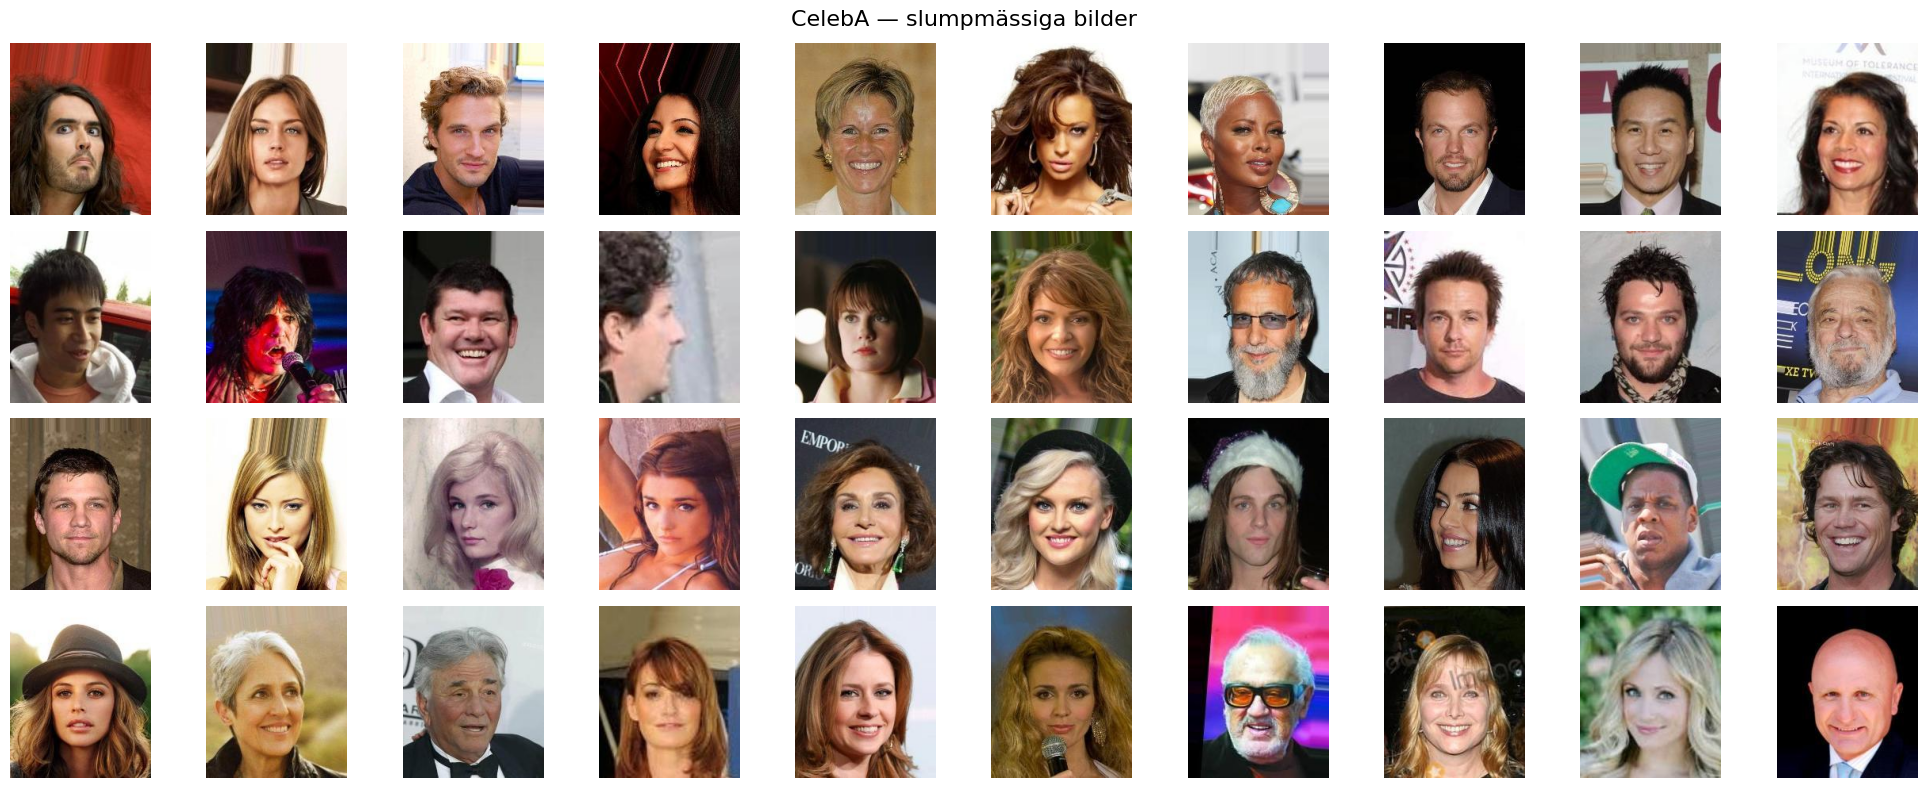

In [2]:

sample = labels.sample(n=40, random_state=42)

fig, axes = plt.subplots(4, 10, figsize=(20, 8))
fig.suptitle('CelebA — slumpmässiga bilder', fontsize=16)

for i, row in enumerate(sample.itertuples()):
    img = Image.open(os.path.join(source_dir, row.image_id))
    axes[i // 10][i % 10].imshow(img)
    axes[i // 10][i % 10].axis('off')

plt.tight_layout()
plt.savefig('presentation/visualizations/celeba_random.png', dpi=150, bbox_inches='tight')
plt.show()


## 25 mustasch + 25 clean — originaldata

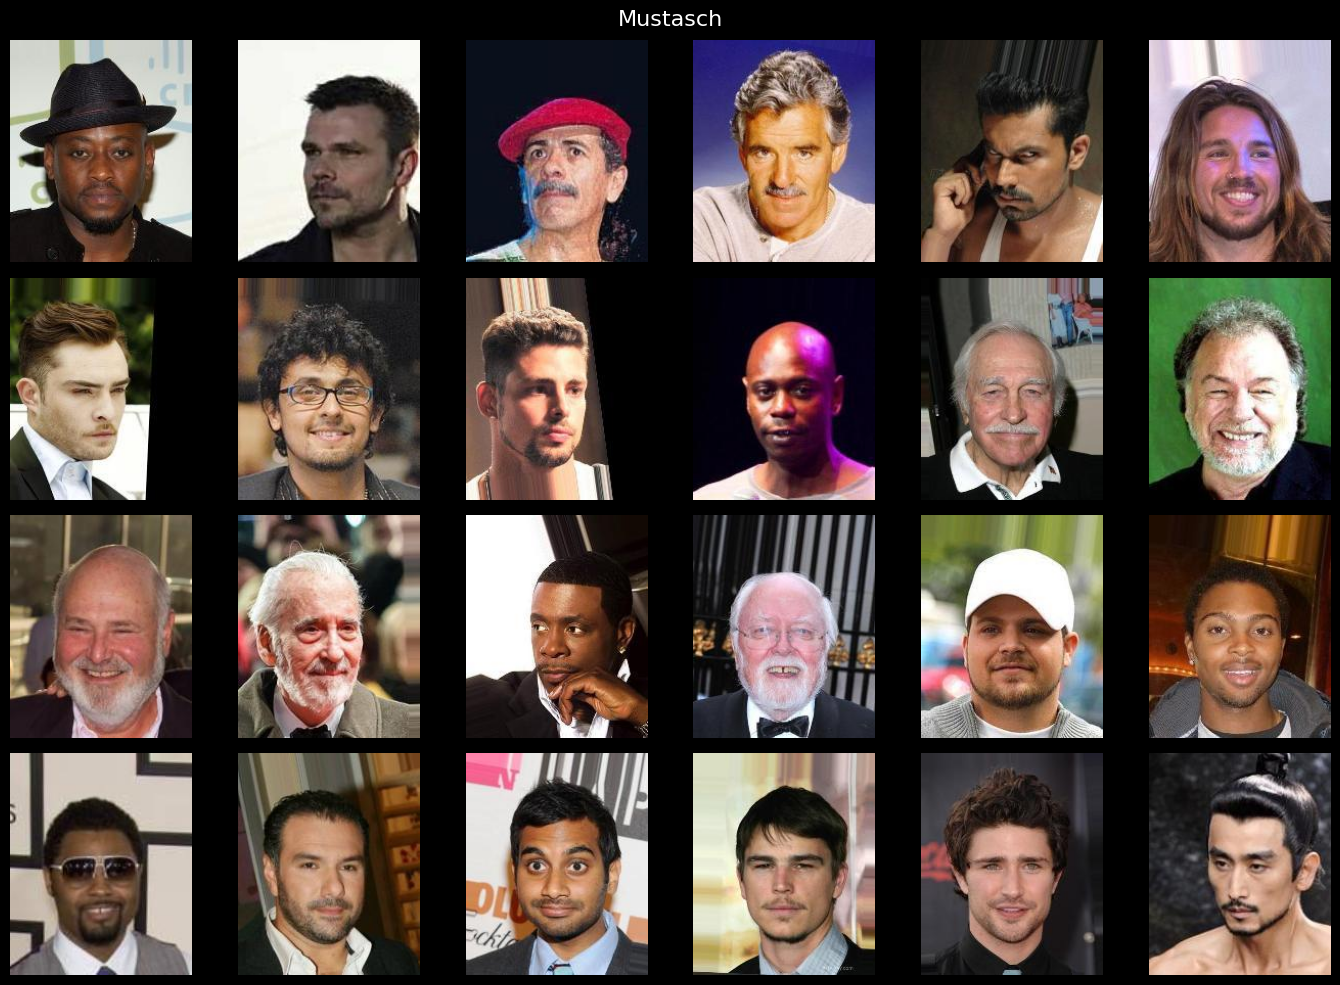

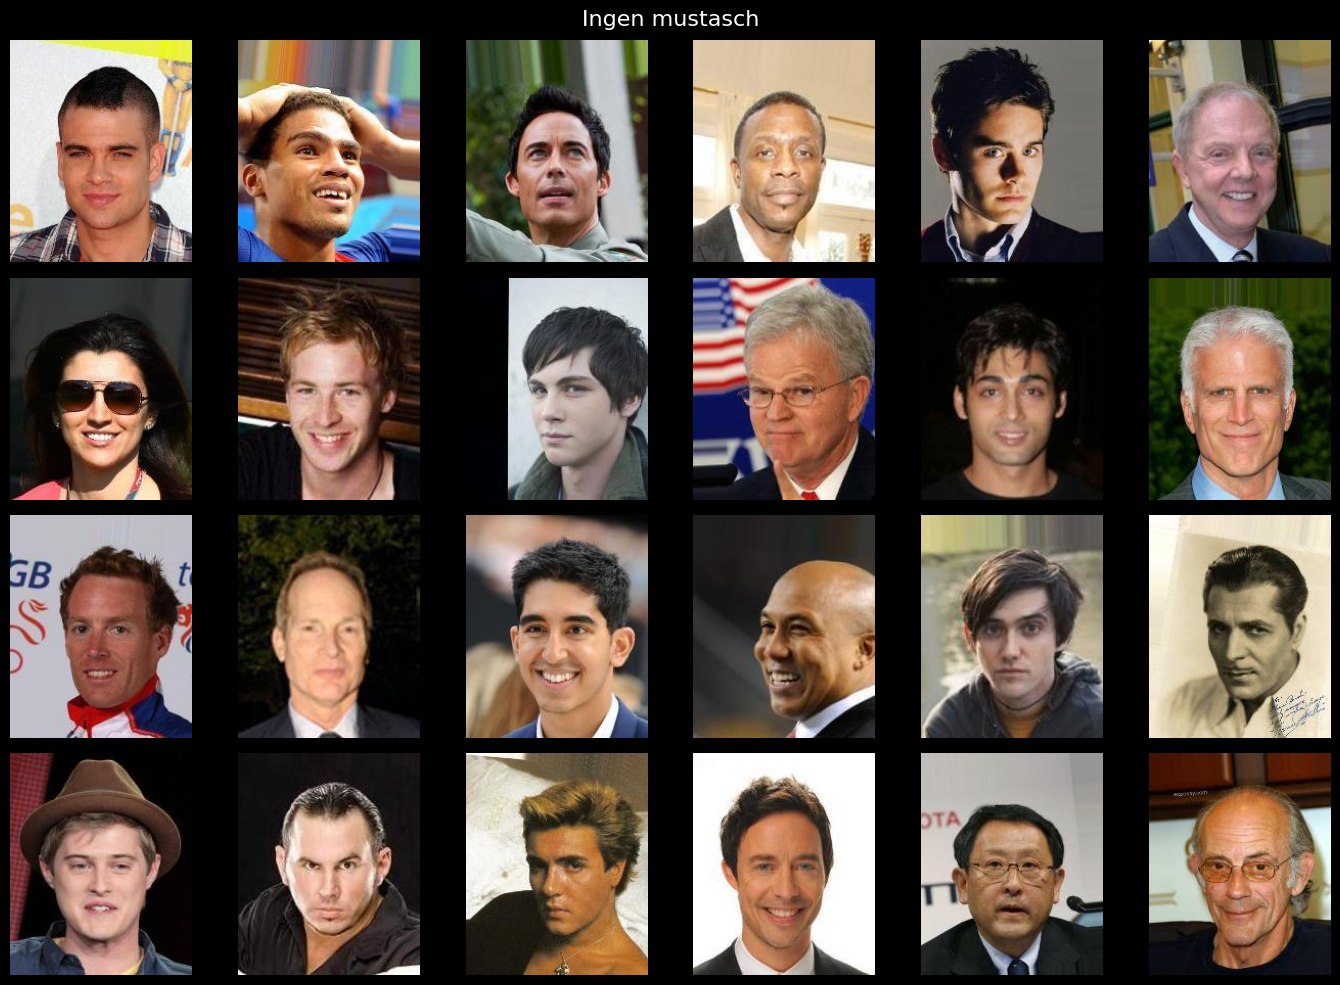

In [8]:
# Mustasch-bild
mustache_sample = men[men['Mustache'] == 1].sample(n=24, random_state=42)

fig, axes = plt.subplots(4, 6, figsize=(14, 10))
fig.patch.set_facecolor('black')
fig.suptitle('Mustasch', fontsize=16, color='white')
for i, row in enumerate(mustache_sample.itertuples()):
    img = Image.open(os.path.join(source_dir, row.image_id))
    axes[i // 6][i % 6].imshow(img)
    axes[i // 6][i % 6].axis('off')
plt.tight_layout()
plt.savefig('presentation/dataset_mustache.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()

# Clean-bild
clean_sample = men[(men['Mustache'] == -1) & (men['No_Beard'] == 1)].sample(n=24, random_state=42)

fig, axes = plt.subplots(4, 6, figsize=(14, 10))
fig.patch.set_facecolor('black')
fig.suptitle('Ingen mustasch', fontsize=16, color='white')
for i, row in enumerate(clean_sample.itertuples()):
    img = Image.open(os.path.join(source_dir, row.image_id))
    axes[i // 6][i % 6].imshow(img)
    axes[i // 6][i % 6].axis('off')
plt.tight_layout()
plt.savefig('presentation/dataset_clean.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()

## Confusion matrix — Mustache Detector

Found 10952 files belonging to 2 classes.
Using 2190 files for validation.


2026-06-17 05:42:51.432983: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


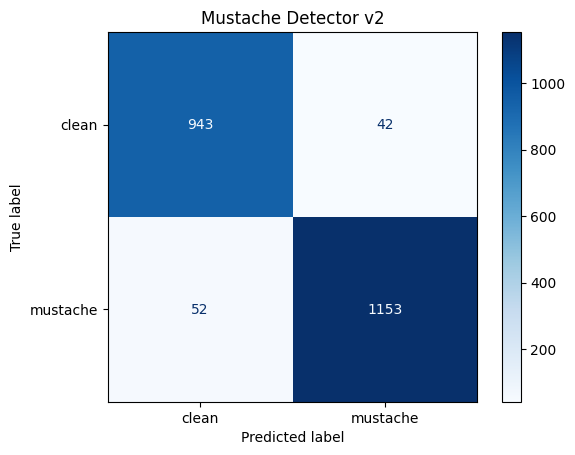

Sparad: presentation/confusion_mustache.png


In [7]:
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

mustache_model = tf.keras.models.load_model('models/mustache_detector2.keras')

val_ds = tf.keras.utils.image_dataset_from_directory(
    'data/dataset_v3',
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(178, 178),
    batch_size=32,
    label_mode='binary'
)

y_true, y_pred = [], []
for images, labels_batch in val_ds:
    preds = mustache_model.predict(images, verbose=0).flatten()
    y_true.extend(labels_batch.numpy().astype(int))
    y_pred.extend((preds > 0.5).astype(int))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=val_ds.class_names)
disp.plot(values_format='d', cmap='Blues')
plt.title('Mustache Detector v2')
plt.savefig('presentation/confusion_mustache.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sparad: presentation/confusion_mustache.png')

## Confusion matrix — Epic Detector

Found 597 files belonging to 2 classes.
Using 119 files for validation.


2026-06-03 13:07:42.524761: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


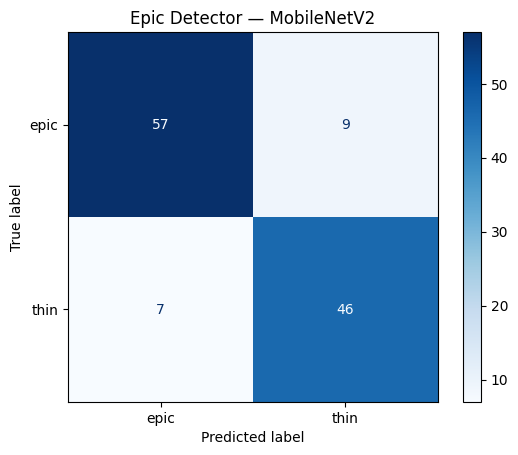

Sparad: presentation/confusion_epic.png


In [4]:
epic_model = tf.keras.models.load_model('models/epic_detector.keras')

epic_val_ds = tf.keras.utils.image_dataset_from_directory(
    'data/epic_dataset',
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(128, 128),
    batch_size=16,
    label_mode='binary'
)

y_true, y_pred = [], []
for images, labels_batch in epic_val_ds:
    preds = epic_model.predict(images, verbose=0).flatten()
    y_true.extend(labels_batch.numpy().astype(int))
    y_pred.extend((preds > 0.5).astype(int))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=epic_val_ds.class_names)
disp.plot(values_format='d', cmap='Blues')
plt.title('Epic Detector — MobileNetV2')
plt.savefig('presentation/confusion_epic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sparad: presentation/confusion_epic.png')

## Top 25 mest episka från valideringen

In [4]:
images_list, true_labels, pred_probs = [], [], []

for images, labels_batch in epic_val_ds:
    preds = epic_model.predict(images, verbose=0).flatten()
    images_list.append(images.numpy())
    true_labels.append(labels_batch.numpy().flatten())
    pred_probs.append(preds)

images_arr = np.concatenate(images_list)
true_arr   = np.concatenate(true_labels)
pred_arr   = np.concatenate(pred_probs)
epic_scores = 1 - pred_arr

top_idx = np.argsort(epic_scores)[-25:][::-1]

fig, axes = plt.subplots(5, 5, figsize=(12, 12))
fig.patch.set_facecolor('black')
fig.suptitle('Top mustascher', fontsize=16, color='white')
for i, idx in enumerate(top_idx):
    axes[i // 5][i % 5].imshow(images_arr[idx].astype('uint8'))
    axes[i // 5][i % 5].set_title(f"{epic_scores[idx]*100:.0f}%", fontsize=8, color='white')
    axes[i // 5][i % 5].axis('off')
    axes[i // 5][i % 5].set_facecolor('black')
plt.tight_layout()
plt.savefig('presentation/top25_epic.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()

NameError: name 'epic_val_ds' is not defined

## Grad-CAM — vad tittar modellen på?

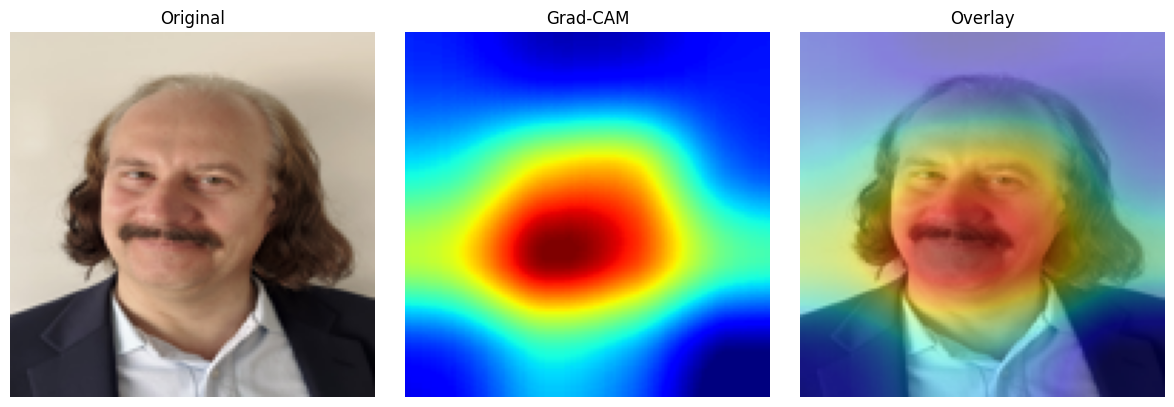

In [29]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

epic_model = tf.keras.models.load_model('models/epic_detector.keras')

# Byt till valfri bild
img_path = 'presentation/vlad3.jpg'
img = Image.open(img_path).convert('RGB').resize((128, 128))
img_array = np.expand_dims(np.array(img), axis=0)

img_normalized = tf.cast(img_array, tf.float32) / 127.5 - 1
mobilenet_layer = epic_model.get_layer('mobilenetv2_1.00_128')

with tf.GradientTape() as tape:
    x = epic_model.get_layer('sequential_4')(img_normalized, training=False)
    x = epic_model.get_layer('rescaling_2')(x, training=False)
    conv_out = mobilenet_layer(x, training=False)
    tape.watch(conv_out)
    x = epic_model.get_layer('global_average_pooling2d_2')(conv_out, training=False)
    x = epic_model.get_layer('dropout_2')(x, training=False)
    predictions = epic_model.get_layer('dense_2')(x, training=False)
    class_channel = predictions[:, 0]

grads = tape.gradient(class_channel, conv_out)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
heatmap = tf.reduce_mean(conv_out[0] * pooled_grads, axis=-1)
heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
heatmap = heatmap.numpy()

img_display = np.array(img)
heatmap_resized = np.array(Image.fromarray(np.uint8(heatmap * 255)).resize((128, 128)))
heatmap_colored = np.uint8(plt.cm.jet(heatmap_resized / 255)[:, :, :3] * 255)
superimposed = np.uint8(img_display * 0.6 + heatmap_colored * 0.4)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_display)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(heatmap_resized, cmap='jet')
axes[1].set_title('Grad-CAM')
axes[1].axis('off')
axes[2].imshow(superimposed)
axes[2].set_title('Overlay')
axes[2].axis('off')
plt.tight_layout()
plt.savefig('presentation/gradcam.png', dpi=150, bbox_inches='tight')
plt.show()

Found 597 files belonging to 2 classes.
Using 119 files for validation.


2026-06-07 10:32:02.748014: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


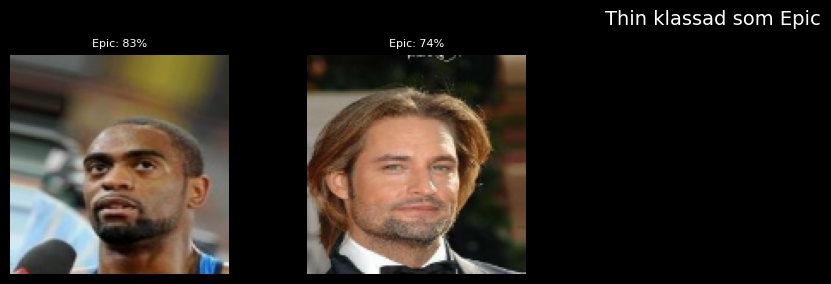

In [31]:
epic_val_ds = tf.keras.utils.image_dataset_from_directory(
    'data/epic_dataset',
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(128, 128),
    batch_size=16,
    label_mode='binary'
)

images_list, true_labels, pred_probs = [], [], []
for images, labels_batch in epic_val_ds:
    preds = epic_model.predict(images, verbose=0).flatten()
    images_list.append(images.numpy())
    true_labels.append(labels_batch.numpy().flatten())
    pred_probs.append(preds)

images_arr = np.concatenate(images_list)
true_arr   = np.concatenate(true_labels)
pred_arr   = np.concatenate(pred_probs)

# True: thin (1) men modellen tror epic (låg thin_prob)
fp_idx = np.where((true_arr == 1) & (pred_arr < 0.3))[0]
fp_sorted = fp_idx[np.argsort(pred_arr[fp_idx])]

plt.figure(figsize=(15, 10), facecolor='black')
for i, idx in enumerate(fp_sorted[:20]):
    ax = plt.subplot(4, 5, i + 1)
    plt.imshow(images_arr[idx].astype('uint8'))
    plt.title(f'Epic: {(1-pred_arr[idx])*100:.0f}%', color='white', fontsize=8)
    plt.axis('off')
    ax.set_facecolor('black')
plt.suptitle('Thin klassad som Epic', color='white', fontsize=14)
plt.tight_layout()
plt.savefig('presentation/false_epic.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()